# Module 5 - Activity 2: Naive Bayes Classification (Titanic)

**Goal:** predict a passenger's **survival (Survived: 0/1)** - a *classification* problem - using a **Gaussian Naive Bayes** classifier.

This is the pivot from Assessment 1: there we predicted a **number** (wine quality) and measured **R^2 / RMSE**. Here we predict a **label** (survived yes/no) and measure **accuracy / precision / recall** via a **confusion matrix**.

**Why Gaussian NB?** Our first feature, `Fare`, is **continuous**, so we assume it is normally distributed *within each class* (one bell curve for survivors, one for non-survivors). That per-class modelling is what makes Naive Bayes a **generative** classifier.

**The Bayes flip (the whole trick):** NB learns `P(Fare | Survived)` and the prior `P(Survived)`, then uses Bayes' rule to invert it into what we actually want, `P(Survived | Fare)`:

$$P(\text{Survived}\mid \text{Fare}) = \frac{P(\text{Fare}\mid \text{Survived})\;\cdot\;P(\text{Survived})}{P(\text{Fare})}$$


In [1]:
# How to run: system python3 (Homebrew 3.14), libs installed with --break-system-packages
# Requires: scikit-learn, pandas, numpy, matplotlib  | Data: ./titanic.csv (saved locally)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42  # fixed seed -> reproducible split (no data leakage)

df = pd.read_csv("titanic.csv")
print("shape:", df.shape)
df[["Survived", "Fare", "Pclass", "Sex", "Age"]].head()

shape: (891, 12)


,Survived,Fare,Pclass,Sex,Age
0,0,7.2500,3,male,22.0
1,1,71.2833,1,female,38.0
2,1,7.9250,3,female,26.0
3,1,53.1000,1,female,35.0
4,0,8.0500,3,male,35.0


## 1. The simplest model: survival from `Fare` alone

One continuous feature in, one label out. We expect this to be **weak** - fare is only a proxy for wealth/class - but it makes the mechanics crystal clear.

In [2]:
X = df[["Fare"]].copy()       # continuous feature -> Gaussian NB
y = df["Survived"].copy()     # label: 1 = survived, 0 = died

# Class balance = the PRIOR P(Survived) that Bayes starts from
print("Class balance P(y):")
print(y.value_counts(normalize=True).rename({0: "died", 1: "survived"}).round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("\ntrain:", X_train.shape[0], "| test:", X_test.shape[0])

Class balance P(y):
Survived
died        0.616
survived    0.384
Name: proportion, dtype: float64

train: 712 | test: 179


In [3]:
nb = GaussianNB().fit(X_train, y_train)
preds = nb.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, preds), 3))
print("\nclass_prior_  (this IS P(Survived), the prior in Bayes' rule):")
print("  died:", round(nb.class_prior_[0], 3), "| survived:", round(nb.class_prior_[1], 3))
print("\nWhat NB learned about Fare INSIDE each class  -> P(Fare | class):")
for cls, mean, var in zip(nb.classes_, nb.theta_.ravel(), nb.var_.ravel()):
    label = "survived" if cls == 1 else "died"
    print(f"  {label:8s}: mean fare = {mean:7.2f}, std = {np.sqrt(var):6.2f}")

Accuracy: 0.654

class_prior_  (this IS P(Survived), the prior in Bayes' rule):
  died: 0.617 | survived: 0.383

What NB learned about Fare INSIDE each class  -> P(Fare | class):
  died    : mean fare =   21.39, std =  30.64
  survived: mean fare =   48.60, std =  63.64


## 2. Read the confusion matrix (NOT just accuracy)

Accuracy alone lies on imbalanced data - this is the **base-rate** lesson from Resource 1 (Westbury). The confusion matrix shows *where* the model is right and wrong:

```
                 predicted DIED   predicted SURVIVED
actual DIED            TN                FP          <- false alarm
actual SURVIVED        FN                TP
                       ^ missed survivor
```
- **Precision** (survived) = of those it *called* survivors, how many really were. (cost of false alarms)
- **Recall** (survived) = of the real survivors, how many it *caught*. (cost of misses)

Confusion matrix:
 [[103   7]
 [ 55  14]]

               precision    recall  f1-score   support

        died       0.65      0.94      0.77       110
    survived       0.67      0.20      0.31        69

    accuracy                           0.65       179
   macro avg       0.66      0.57      0.54       179
weighted avg       0.66      0.65      0.59       179



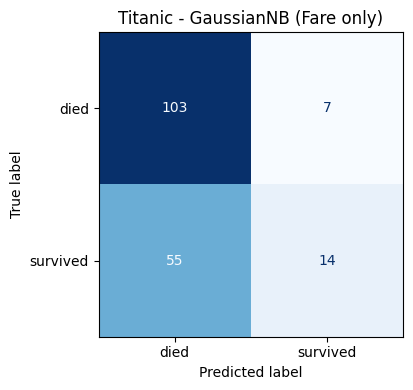

In [4]:
cm = confusion_matrix(y_test, preds)
print("Confusion matrix:\n", cm)
print("\n", classification_report(y_test, preds, target_names=["died", "survived"]))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["died", "survived"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Titanic - GaussianNB (Fare only)")
plt.tight_layout(); plt.show()

## 3. SEE the "generative" part: the two bell curves NB learned

This is the payoff for the generative-vs-discriminative idea. A **generative** model literally learns *what the feature looks like inside each class* - here, one Gaussian for survivors' fares and one for non-survivors'. To classify a new passenger it asks: *"does this fare look more like the survivor curve or the died curve?"* (then weights by the prior). A **discriminative** model (e.g. logistic regression) would skip the curves and learn the decision boundary directly.

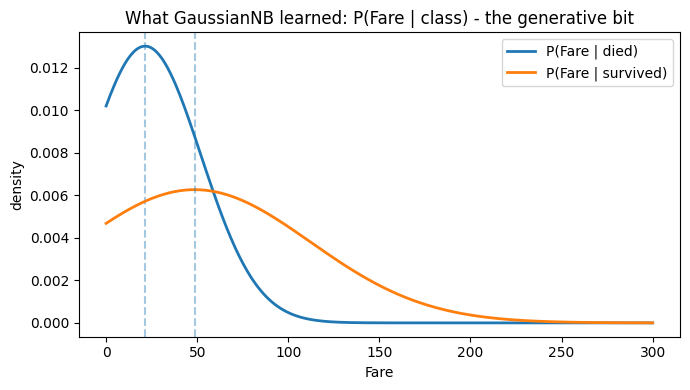

Survivors paid more on average -> higher fare nudges the posterior toward 'survived'.


In [5]:
x_grid = np.linspace(0, 300, 400)
fig, ax = plt.subplots(figsize=(7, 4))
for cls in nb.classes_:
    mean = nb.theta_[cls == nb.classes_][0, 0]
    std = np.sqrt(nb.var_[cls == nb.classes_][0, 0])
    pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid - mean) / std) ** 2)
    label = "survived" if cls == 1 else "died"
    ax.plot(x_grid, pdf, label=f"P(Fare | {label})", linewidth=2)
    ax.axvline(mean, linestyle="--", alpha=0.4)
ax.set_xlabel("Fare"); ax.set_ylabel("density")
ax.set_title("What GaussianNB learned: P(Fare | class) - the generative bit")
ax.legend(); plt.tight_layout(); plt.show()
print("Survivors paid more on average -> higher fare nudges the posterior toward 'survived'.")

## 4. Honest limitation + a quick extension

Fare alone is a **weak** predictor. The strongest survival signals are `Sex` and `Pclass`. Let's add a few features to show the lift. We encode `Sex`, fill missing `Age`, and keep using GaussianNB (treating the encoded values as continuous - a deliberate simplification worth naming in the forum).

In [6]:
feat = df[["Fare", "Pclass", "Age", "Sex"]].copy()
feat["Sex"] = (feat["Sex"] == "female").astype(int)   # 1 = female, 0 = male
feat["Age"] = feat["Age"].fillna(feat["Age"].median()) # simple imputation
Xb, yb = feat, df["Survived"]

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    Xb, yb, test_size=0.2, random_state=RANDOM_STATE, stratify=yb)
nb_big = GaussianNB().fit(Xb_tr, yb_tr)
preds_big = nb_big.predict(Xb_te)

print("Fare only      -> accuracy:", round(accuracy_score(y_test, preds), 3))
print("Fare+Pclass+Age+Sex -> accuracy:", round(accuracy_score(yb_te, preds_big), 3))
print("\n", classification_report(yb_te, preds_big, target_names=["died", "survived"]))

Fare only      -> accuracy: 0.654
Fare+Pclass+Age+Sex -> accuracy: 0.765

               precision    recall  f1-score   support

        died       0.81      0.80      0.81       110
    survived       0.69      0.71      0.70        69

    accuracy                           0.77       179
   macro avg       0.75      0.76      0.75       179
weighted avg       0.77      0.77      0.77       179



## 5. Forum answers to prepare

- **How realistic is predicting survival from fare alone?** Weak - fare is just a proxy for class; it ignores `Sex` and `Age`, the strongest signals. Adding them lifts accuracy (see section 4).
- **What does the conditional-independence ("naive") assumption cost here?** NB assumes features are independent *given the class* (e.g. that `Fare` and `Pclass` carry separate information). In reality fare and class are strongly correlated, so NB double-counts that signal - yet it still classifies well, which is the famous robustness of Naive Bayes.
- **Where did Bayes enter?** `class_prior_` is `P(Survived)`; the per-class fare curves are `P(Fare | Survived)`; Bayes' rule combined them into `P(Survived | Fare)`, which `.predict()` thresholds at 0.5.

**Recall (close the loop, 3 lines, no peeking):** (1) generative learns ___, discriminative learns ___; (2) Bayes' rule served to ___; (3) the confusion matrix told me ___.
